# Yin-Yang Model Inference with Koopman

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torchvision import datasets, transforms
from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    safetensors_metadata_parser,
)
from learningdynamics.koopman_inference import inference_with_koopman
from learningdynamics.visualization import plot_decision_boundary_movie, plot_decision_boundary_koopman
from learningdynamics.datasets import YinYangBinaryDataset

from matplotlib.animation import FuncAnimation
import seaborn as sns
import torch.nn as nn

from torcheval.metrics import MulticlassAccuracy
from torch.utils.data import DataLoader, Subset
import numpy as np
import warnings
from learningdynamics.utils import getActivation
import torch
import math


In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [ ]:
LAYER_START = 1

In [ ]:
file_path = f"../saved_weights/yinyang_start{LAYER_START}_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
NUM_STATES = literal_eval(metadata["num_states"])
NUM_ITERATIONS = literal_eval(metadata["num_iterations"])
NUM_STATES_OF_INTEREST = literal_eval(metadata["num_usable_states"])
data = load_file(file_path)

#### Update dataset

In [ ]:
NUM_TRAJECTORIES = 5000
NUM_STATES = NUM_STATES

supplements =  0
NUM_DELAYS = (NUM_ITERATIONS-2) + NUM_ITERATIONS*supplements
# NUM_DELAYS = 10

In [ ]:
t = np.arange(0, NUM_ITERATIONS, 1)

#### Learn Koopman Operator

In [ ]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
)
test_states = reshape_append_time(data["test_states"][:NUM_ITERATIONS, :, :NUM_STATES])
observables = pk.observables.TimeDelay(delay=1, n_delays=NUM_DELAYS)

In [ ]:
# regressor = pk.regression.EDMD(svd_rank=90)
regressor = pk.regression.EDMD()
# regressor = DMD(svd_rank=RANK)

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=10), regressor=EDMD())

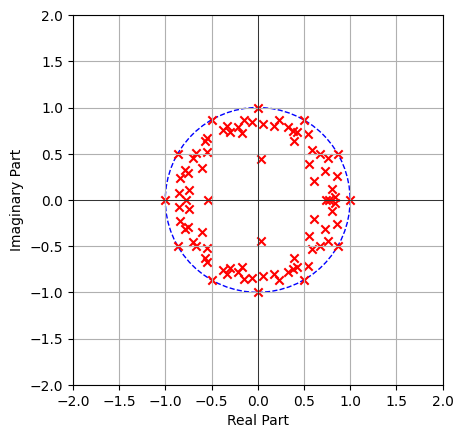

In [ ]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.diag(dmd_model.lamda)

filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.1]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    filtered_eigenvals.real, filtered_eigenvals.imag, color="r", marker="x"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")

# Show the plot
plt.show()

In [ ]:
NUM_SAMPLES = 4000
test_set = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)

In [ ]:
# Load model
file_path = f"../saved_weights/yinyang_start{LAYER_START}_scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
)
_ = load_model(scaled_model, file_path, device="cuda:0")

In [ ]:
out, accuracy = inference_with_koopman(
    nn_model=scaled_model,
    dmd_model=dmd_model,
    test_set=test_set,
    layer_start=literal_eval(metadata["layer_start"]),
    num_iterations=NUM_ITERATIONS,
    num_delays=NUM_DELAYS,
    num_usable_states=NUM_STATES_OF_INTEREST,
    test_size=NUM_SAMPLES,
)
print(accuracy)

tensor(0.9120)
